# Section 1.3 — Processing-time construction and assumption audit

This notebook fits and evaluates **active service time per work session**. The long
`suspend → resume` waits and the `complete` / `ate_abort` / `withdraw` outcomes are
modelled separately by the lifecycle state machine.

This notebook audits the fitted inputs and model artifacts. It does not retrain or
rerun the simulator. Report-facing validation, figures, and numerical conclusions
belong to `03_process_times.ipynb`; keeping those responsibilities separate avoids
two notebooks presenting different versions of the same result.


## Scope and interface with the resource perspective

BPIC-17 work items alternate short active sessions with potentially long suspended
waits. Treating the whole `start → complete` span as processing time held a resource
through nights, customer waits, and repeated suspensions. The active model instead
uses one duration draw for each `start` or `resume` session and releases the resource
at `suspend`.

The engine separates three clocks: queueing is `schedule → start`, hands-on work is
the sum of `start/resume → suspend/terminal` intervals, and external waiting is the
calendar-adjusted `suspend → resume-ready` residual. Normal allocation and calendars
then add a fresh reacquisition delay before the logged `resume`.

`simulation.main` still defaults to `--lifecycle-mode legacy`, while the experiment
runner and every 04 evaluation notebook explicitly select active mode. This notebook
therefore audits the versioned active inputs actually used for the report evaluation.


In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The notebook may be opened from notebooks/ or from the repository root.
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import extract_log_info as E
import train_processing_time_model as T
from analysis.tum_style import (
    TUM_BLUE, TUM_GREEN, TUM_ORANGE, TUM_VIOLET,
    apply_tum_style,
)
from analysis.availability import YearlyAvailability
from simulation.components import permissions as permission_models
from simulation.components.case_attributes import CaseAttributeSampler
from simulation.components.lifecycle_params import LifecycleParameters
from simulation.main import (
    ACTIVE_INPUTS_PATH,
    ACTIVE_MODEL_PATH,
    AVAILABILITY_MODEL_PATH,
    CASE_ATTRIBUTES_PATH,
    DEFAULT_BPMN_PATH,
    ORGMODEL_PATH,
    RANDOM_SEED,
    START_DATETIME,
)
apply_tum_style()

LOG_CANDIDATES = [
    ROOT / 'BPIChallenge2017.xes', ROOT / 'BPIChallenge2017.xes.gz',
    ROOT / 'data/BPIChallenge2017.xes', ROOT / 'data/BPIChallenge2017.xes.gz',
]
LOG = next((candidate for candidate in LOG_CANDIDATES if candidate.is_file()), None)
RAW_LOG = None
ACTIVE_SESSIONS = None
INPUTS_PATH = Path(ACTIVE_INPUTS_PATH)
METRICS_PATH = ROOT / 'output/models/processing_time_metrics_active.json'
METRICS = json.loads(METRICS_PATH.read_text()) if METRICS_PATH.is_file() else None
ARTIFACT = Path(ACTIVE_MODEL_PATH)
LIFECYCLE = LifecycleParameters.from_file(INPUTS_PATH)

# Deliberately lazy: opening the notebook never loads a large artifact.
def load_artifact():
    if not ARTIFACT.is_file():
        raise FileNotFoundError(
            f'Missing {ARTIFACT.relative_to(ROOT)}; run python setup_models.py --lifecycle active first.'
        )
    artifact = joblib.load(ARTIFACT)
    if artifact.get('target') != 'active_session_seconds' or artifact.get('lifecycle_schema') != 'active_v1':
        raise ValueError('The selected model is not an active-v1 lifecycle artifact.')
    return artifact

def load_resource_models(seed=RANDOM_SEED):
    """Prepare the same fitted collaborators that simulation.main injects."""
    calendar = YearlyAvailability.from_json(AVAILABILITY_MODEL_PATH)
    permissions = permission_models.OrgModelPermissions.from_json(ORGMODEL_PATH)
    permissions.self_check()
    case_attributes = CaseAttributeSampler.from_json(CASE_ATTRIBUTES_PATH, seed=seed)
    return calendar, permissions, case_attributes


## Basic 1 — one active-session distribution per work activity

The dependency-light active baseline samples a fitted parametric distribution for
each `W_` activity session. Lifecycle hazards decide whether a session completes or
suspends; a separate residual distribution controls when suspended work becomes
ready to re-enter the resource queue. Atomic `A_` and `O_` events retain synthetic
start/complete durations because BPIC-17 has no pairs from which to fit them. Their
influence is reported separately and tested with a zero-duration lower bound in the
04 evaluation notebooks.


In [2]:
params = LIFECYCLE.processing_times
families = pd.Series([family for family, _ in params.values()]).value_counts()
summary = pd.DataFrame({
    'activities': [len(params)],
    'median session-end P(complete)': [np.median(list(LIFECYCLE.session_end_probs.values()))],
    'median suspended-end P(resume)': [np.median(list(LIFECYCLE.suspend_end_probs.values()))],
}, index=['active lifecycle'])
display(summary)
display(families.rename_axis('family').to_frame('activities'))


,activities,median session-end P(complete),median suspended-end P(resume)
active lifecycle,8,0.129249,0.786965


,activities
family,
lognorm,7
weibull_min,1


[load] Reading XES with pm4py: /Users/danielsich/dev/Ent/bpic17-process-mining-group-assignment/BPIChallenge2017.xes …


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 1/31509 [00:00<2:57:41,  2.96it/s]

parsing log, completed traces ::   0%|          | 77/31509 [00:00<02:18, 227.58it/s]

parsing log, completed traces ::   1%|          | 222/31509 [00:00<00:52, 591.02it/s]

...

parsing log, completed traces ::  99%|█████████▉| 31330/31509 [00:24<00:00, 1453.97it/s]

parsing log, completed traces :: 100%|█████████▉| 31482/31509 [00:24<00:00, 1469.14it/s]

parsing log, completed traces :: 100%|██████████| 31509/31509 [00:25<00:00, 1259.76it/s]

[load] 1,202,267 events, 31,509 cases, 26 activities.


[instances] 127,210 W_ work-item instances → 254,370 active sessions → 254,370 after filter (0 < d ≤ 7d).
254,370 active sessions | median 1.63 min | p95 18.2 min | max 1147 min


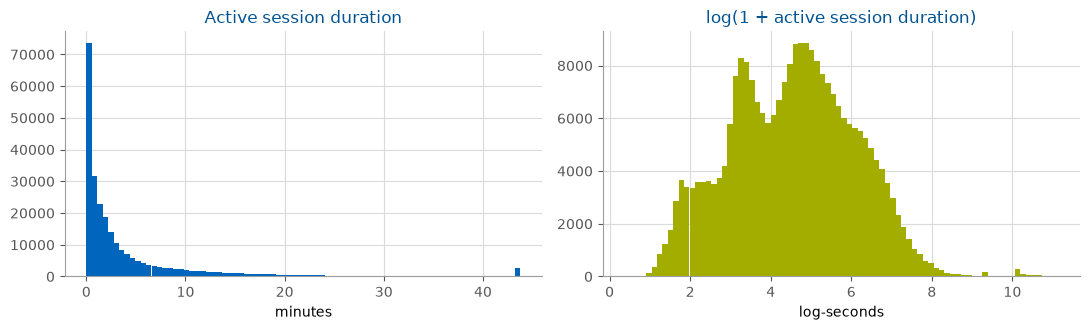

In [3]:
# Optional, log-dependent diagnostic. It only reads the source log; it does not fit or run.
if LOG is None:
    print('Raw log not found — add it to the repository root or data/ to draw this diagnostic.')
else:
    RAW_LOG = T.load_log(LOG)
    ACTIVE_SESSIONS = T.build_active_sessions(RAW_LOG)
    duration_m = ACTIVE_SESSIONS['duration_s'] / 60
    print(
        f'{len(ACTIVE_SESSIONS):,} active sessions | median {duration_m.median():.2f} min | '
        f'p95 {duration_m.quantile(.95):.1f} min | max {duration_m.max():.0f} min'
    )
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
    axes[0].hist(duration_m.clip(upper=duration_m.quantile(.99)), bins=80, color=TUM_BLUE)
    axes[0].set(title='Active session duration', xlabel='minutes')
    axes[1].hist(np.log1p(ACTIVE_SESSIONS['duration_s']), bins=80, color=TUM_GREEN)
    axes[1].set(title='log(1 + active session duration)', xlabel='log-seconds')
    plt.tight_layout()
    plt.show()


## Lifecycle inventory, churn, and model parameters

The state machine is `schedule → start → (suspend → resume)* → complete | ate_abort | withdraw`.
It applies to `W_` items only and is keyed by `work_item_id`. In BPIC-17, 99.8% of
cases have at most one open work item and only 17.5% of resumes retain the previous
resource. Those measurements justify the serial case approximation and pool-based
resource reacquisition.

The fitted resume gap is a calendar-aware residual, not a causal estimate of customer
waiting: only the contiguous deterministic off-shift tail before the historical
resume is removed; the simulated queue and calendar add a new allocation delay.


In [4]:
raw_active_inputs = json.loads(INPUTS_PATH.read_text())['lifecycle']
hazards = pd.DataFrame({
    'P(complete | session end)': LIFECYCLE.session_end_probs,
    'P(resume | suspended end)': LIFECYCLE.suspend_end_probs,
    'resume residual family': {a: family for a, (family, _) in LIFECYCLE.resume_gap_params.items()},
    'resume residual P(zero)': LIFECYCLE.resume_gap_zero_probs,
    'withdraw family': {a: family for a, (family, _) in LIFECYCLE.withdraw_hazard.items()},
}).sort_index()
active_work = set(LIFECYCLE.processing_times)
assert len(active_work) == 8
assert active_work == set(LIFECYCLE.session_end_probs)
assert active_work == set(LIFECYCLE.suspend_end_probs)
assert active_work == set(LIFECYCLE.resume_gap_params)
display(hazards)
boundary_hazards = hazards[
    hazards['P(complete | session end)'].isin([0.0, 1.0])
    | hazards['P(resume | suspended end)'].isin([0.0, 1.0])
]
display(boundary_hazards)

continuation_rows = []
for activity, outcomes in LIFECYCLE.terminal_continuation.items():
    for outcome, choices in outcomes.items():
        continuation_rows.extend(
            {'activity': activity, 'outcome': outcome, 'next': nxt, 'probability': probability}
            for nxt, probability in choices
        )
display(pd.DataFrame(continuation_rows).sort_values(['activity', 'outcome', 'probability'], ascending=[True, True, False]))

if RAW_LOG is not None:
    lifecycle_counts = RAW_LOG['lifecycle'].str.lower().value_counts()
    display(lifecycle_counts.rename('events').to_frame())
    segmented = E.segment_work_items(RAW_LOG)
    churn_rows = []
    for activity, suspends in segmented['suspends_per_instance'].items():
        sessions = segmented['active_sessions'].get(activity, [])
        churn_rows.append({
            'activity': activity,
            'instances': len(suspends),
            'churned': np.mean(np.asarray(suspends) > 0),
            'mean_suspends': np.mean(suspends),
            'median_active_session_s': np.median(sessions) if sessions else np.nan,
        })
    display(pd.DataFrame(churn_rows).sort_values('instances', ascending=False))


,P(complete | session end),P(resume | suspended end),resume residual family,resume residual P(zero),withdraw family
W_Assess potential fraud,0.213636,0.959538,weibull_min,0.116466,expon
W_Call after offers,0.005647,0.483767,weibull_min,0.024271,weibull_min
W_Call incomplete files,0.044863,0.659716,lognorm,0.080177,NaN
W_Complete application,0.365131,0.681940,weibull_min,0.084672,gamma
W_Handle leads,0.714169,0.891989,lognorm,0.192462,lognorm
W_Personal Loan collection,0.000000,1.000000,expon,0.000000,NaN
W_Shortened completion,0.000000,1.000000,expon,0.000000,NaN
W_Validate application,0.217298,0.594243,weibull_min,0.098791,NaN


,P(complete | session end),P(resume | suspended end),resume residual family,resume residual P(zero),withdraw family
W_Personal Loan collection,0.0,1.0,expon,0.0,NaN
W_Shortened completion,0.0,1.0,expon,0.0,NaN


,activity,outcome,next,probability
31,W_Assess potential fraud,ate_abort,A_Denied,0.3810
32,W_Assess potential fraud,ate_abort,W_Validate application,0.2381
33,W_Assess potential fraud,ate_abort,__CASE_END__,0.2143
34,W_Assess potential fraud,ate_abort,W_Call after offers,0.0714
35,W_Assess potential fraud,ate_abort,A_Accepted,0.0476
...,...,...,...,...
42,W_Validate application,complete,W_Assess potential fraud,0.0054
43,W_Validate application,complete,A_Denied,0.0025
44,W_Validate application,complete,W_Validate application,0.0005
45,W_Validate application,complete,A_Validating,0.0004


,events
lifecycle,
complete,475306
suspend,215402
schedule,149104
start,128227
resume,127160
ate_abort,85224
withdraw,21844


,activity,instances,churned,mean_suspends,median_active_session_s
3,W_Validate application,39009,0.890384,1.463252,127.795
2,W_Call after offers,34603,0.899951,1.740167,58.460
1,W_Complete application,31532,0.538945,1.053438,164.218
4,W_Call incomplete files,23013,0.987181,2.574719,87.459
0,W_Handle leads,20446,0.044312,0.068375,65.933
5,W_Assess potential fraud,327,0.923547,3.174312,45.468


**Decision 1 — fit `log(1 + active session duration)`.** Active sessions
remain right-skewed, so context-aware models predict their log transform and invert
with `expm1`. Report log- and raw-scale metrics: the former describes fit across
orders of magnitude, while raw seconds keep large tail errors visible. Elapsed
lifecycle fit is evaluated separately through recomposition of sessions, gaps,
calendar waits, and queue delays.


## Basic 2 — contextual active-session point estimate

`GradientBoostingRegressor` predicts log active-session seconds from the existing
eight-feature contract: activity, allocated resource, previous activity, weekday,
hour, case position, case age, and prior-activity count. Context is computed once at
the work item's first start and duplicated across all its sessions; v1 intentionally
does not use the session index. The oldest 80% of work items train the model and the
newest 20% evaluate temporal generalization.


,split,train sessions,test sessions,log R²,raw R²,MAE (minutes),RMSE (minutes)
0,temporal_80_20,203496,50874,0.087152,-0.016942,4.86643,28.630374


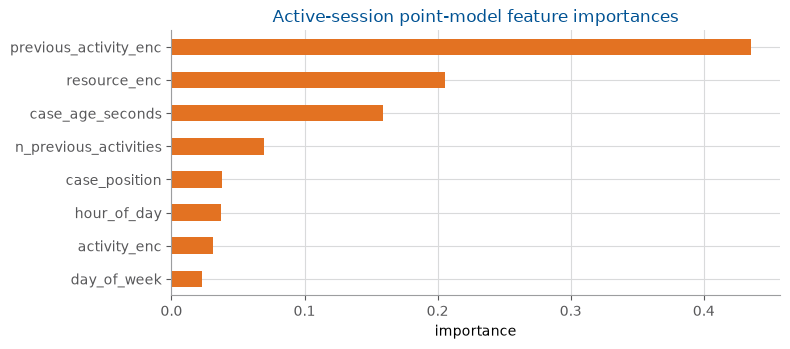

In [5]:
if METRICS is None:
    print('Active metrics are absent — run python setup_models.py --lifecycle active.')
else:
    point = METRICS['point_model']
    display(pd.DataFrame([{
        'split': point['split'],
        'train sessions': point['n_train'],
        'test sessions': point['n_test'],
        'log R²': point['r2_log'],
        'raw R²': point['r2_raw'],
        'MAE (minutes)': point['mae_seconds'] / 60,
        'RMSE (minutes)': point['rmse_seconds'] / 60,
    }]))

    importance = pd.Series(METRICS['feature_importances']).sort_values()
    ax = importance.plot.barh(figsize=(8, 3.6), color=TUM_ORANGE)
    ax.set(title='Active-session point-model feature importances', xlabel='importance')
    plt.tight_layout()
    plt.show()


The resource feature is fixed when the first session starts and reused
throughout that work item's lifecycle, matching the locked feature contract. A resume
still returns through normal permission, calendar, capacity, and allocation checks;
the newly selected resource affects occupancy and resume ownership, but does not
silently change the duration context halfway through an item.


## Advanced I — conditional active-session distribution

The advanced model fits 19 independent gradient-boosting quantile regressors
(`q = 0.05, 0.10, …, 0.95`) over the same work-item context. At runtime it repairs
quantile crossings with a cumulative maximum in log space, then samples the
interpolated inverse CDF. Churn, resume waits, and continuation remain the same
parametric activity-level mechanisms for every duration mode.


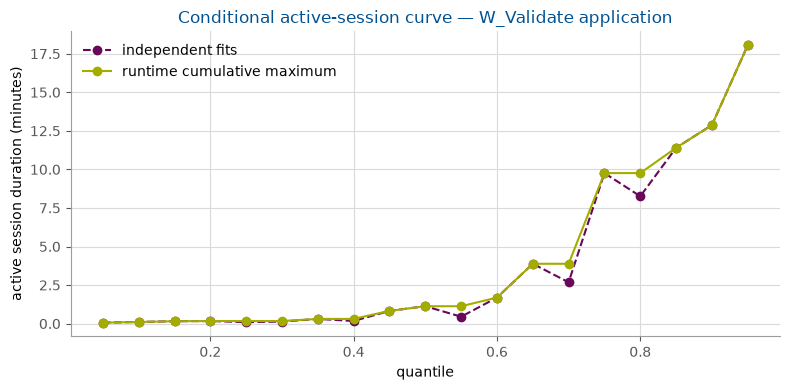

In [6]:
def feature_vector(artifact, activity, resource, previous_activity, *,
                   day=1, hour=11, position=5, case_age_s=3 * 24 * 3600):
    encoders, sentinels = artifact['encoders'], artifact['sentinels']

    def encode(name, value, fallback):
        value = value if value in set(encoders[name].classes_) else fallback
        return int(encoders[name].transform([value])[0])

    values = {
        'activity_enc': encode('activity', activity, sentinels['unknown']),
        'resource_enc': encode('resource', resource, sentinels['unknown']),
        'previous_activity_enc': encode('previous_activity', previous_activity, sentinels['no_prev']),
        'day_of_week': day, 'hour_of_day': hour, 'case_position': position,
        'case_age_seconds': case_age_s, 'n_previous_activities': position,
    }
    return np.asarray([[values[name] for name in artifact['feature_names']]], dtype=float)

# This diagnostic requires the optional trained artifact; it never retrains it.
if ARTIFACT.is_file():
    artifact = load_artifact()
    if artifact.get('quantile_models') is None:
        print('Artifact has only the point model — regenerate with python setup_models.py --lifecycle active.')
    else:
        activities = [a for a in artifact['encoders']['activity'].classes_ if not a.startswith('__')]
        activity = 'W_Validate application' if 'W_Validate application' in activities else activities[0]
        x = feature_vector(artifact, activity, artifact['sentinels']['unknown'], artifact['sentinels']['no_prev'])
        quantiles = [float(q) for q in artifact['quantiles']]
        raw_log = np.asarray([artifact['quantile_models'][q].predict(x)[0] for q in artifact['quantiles']])
        monotone_log = np.maximum.accumulate(raw_log)

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(quantiles, np.expm1(raw_log) / 60, 'o--', color=TUM_VIOLET, label='independent fits')
        ax.plot(quantiles, np.expm1(monotone_log) / 60, 'o-', color=TUM_GREEN, label='runtime cumulative maximum')
        ax.set(xlabel='quantile', ylabel='active session duration (minutes)', title=f'Conditional active-session curve — {activity}')
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print('Trained artifact not found — diagnostic prepared but not executed.')


In [7]:
if METRICS is not None and METRICS.get('quantile_eval') is not None:
    quantile_eval = METRICS['quantile_eval']
    display(pd.DataFrame([{
        'mean pinball loss (log)': quantile_eval['mean_pinball_loss_log'],
        '90% interval coverage': quantile_eval['coverage_90pct_interval'],
        '50% interval coverage': quantile_eval['coverage_50pct_interval'],
        'median-quantile log R²': quantile_eval['r2_log_median_quantile'],
    }]))
else:
    print('Quantile metrics are absent — regenerate the probabilistic artifact first.')


,mean pinball loss (log),90% interval coverage,50% interval coverage,median-quantile log R²
0,0.429416,0.880155,0.496108,0.070904


**Decision 2 — evaluate each stochastic layer at its own level.** Mean
pinball loss and central-interval coverage assess the active-session duration model.
Lifecycle validation then compares terminal-outcome-stratified session sums,
suspend counts, and elapsed `start → complete/ate_abort` or `schedule → withdraw`
times keyed by `work_item_id`. A good duration score alone is not evidence that the
whole lifecycle distribution is calibrated.


## Validated artifacts and report hand-off

The controlled distribution, point-ML, and probabilistic-ML runs already exist under
`output/validation/lifecycle_active`. Reconstructing shell commands here was obsolete
and machine-specific. The cell below verifies those committed inputs and states which
notebook and figures feed the report.


In [8]:
VALIDATION_DIR = ROOT / 'output/validation/lifecycle_active'
MODE_FILES = {
    'Distribution': VALIDATION_DIR / 'distribution.json',
    'Point ML': VALIDATION_DIR / 'ml_model.json',
    'Probabilistic ML': VALIDATION_DIR / 'ml_probabilistic.json',
}
missing_validation = [path for path in MODE_FILES.values() if not path.is_file()]
assert not missing_validation, missing_validation
validation_inventory = pd.DataFrame([
    {
        'sampler': label,
        'completed cases': payload['configuration']['completed_cases'],
        'active-time mean relative error': payload['general_metrics']['processing_times']['mean_rel_err'],
        'case-duration relative error': payload['general_metrics']['case_stats']['case_duration_rel_err'],
    }
    for label, path in MODE_FILES.items()
    for payload in [json.loads(path.read_text())]
]).set_index('sampler')
display(validation_inventory.round(3))

report_handoff = pd.DataFrame({
    'report use': [
        'main processing-time result',
        'appendix model diagnostics',
        'policy evaluation duration mode',
    ],
    'source': [
        '03_process_times.ipynb → 03_lifecycle_time_recomposition.pdf',
        '03_process_times.ipynb → feature importance and interval coverage PDFs',
        '04_evaluation*.ipynb → distribution (not ML)',
    ],
}).set_index('report use')
display(report_handoff)


,completed cases,active-time mean relative error,case-duration relative error
sampler,,,
Distribution,1358,0.213,0.906
Point ML,1353,0.740,0.905
Probabilistic ML,1367,0.368,0.900


,source
report use,
main processing-time result,03_process_times.ipynb → 03_lifecycle_time_rec...
appendix model diagnostics,03_process_times.ipynb → feature importance an...
policy evaluation duration mode,04_evaluation*.ipynb → distribution (not ML)


## Reproducibility and reporting

- Regenerate lifecycle tables with `python extract_log_info.py --log BPIChallenge2017.xes --out simulation_inputs_active.json --lifecycle`.
- Rebuild the point and quantile artifacts with `python setup_models.py --lifecycle active`; active and legacy artifacts remain versioned separately.
- Regenerate the controlled validation JSON before changing numerical claims in `03_process_times.ipynb` or the report.
- Treat the 17.5% same-resource resume rate as a historical calibration target, not a policy invariant.
- Do not infer that the policy evaluation uses ML durations: every 04 notebook records `processing_time_mode=distribution` in its cache and exported configuration.
